In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import about, basis, destroy, mcsolve, mesolve, sigmam, sigmax
import pandas as pd
import lmfit
import corner
import emcee
from pylab import *
ion()

%matplotlib inline

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


consider a simple oscillator Hamiltonian H=a†a

In [3]:
# number of modes
N = 2
# Destroy operator
a = destroy(N)
# oscillator Hamiltonian
H = a.dag() * a
# Initial excited (1) state
psi0 = basis(N, 1)

In [4]:
#dissipative terms
gamma_relax=5.0
k=5

#collapse operator
c_ops = []
c_ops.append(np.sqrt(k) * sigmam()) #c1= sqrt(kappa)*signam_- ------excitation
c_ops.append(np.sqrt(gamma_relax)*a) #c2= sqrt(kappa)*a -----decay


In [5]:
ntraj = [1, 5, 15, 904]  # number of MC trajectories
t_final=2
tlist = np.linspace(0, t_final, 100)

# Solve using MCSolve for different ntraj
mc_try = mcsolve(H, psi0, tlist, c_ops, [a.dag() * a], ntraj)
me = mesolve(H, psi0, tlist, c_ops, [a.dag() * a])

10.1%. Run time:   0.24s. Est. time left: 00:00:00:02
20.0%. Run time:   0.35s. Est. time left: 00:00:00:01
30.1%. Run time:   0.49s. Est. time left: 00:00:00:01
40.0%. Run time:   0.61s. Est. time left: 00:00:00:00
50.0%. Run time:   0.73s. Est. time left: 00:00:00:00
60.1%. Run time:   0.84s. Est. time left: 00:00:00:00
70.0%. Run time:   0.97s. Est. time left: 00:00:00:00
80.1%. Run time:   1.08s. Est. time left: 00:00:00:00
90.0%. Run time:   1.20s. Est. time left: 00:00:00:00
100.0%. Run time:   1.29s. Est. time left: 00:00:00:00
Total run time:   1.30s


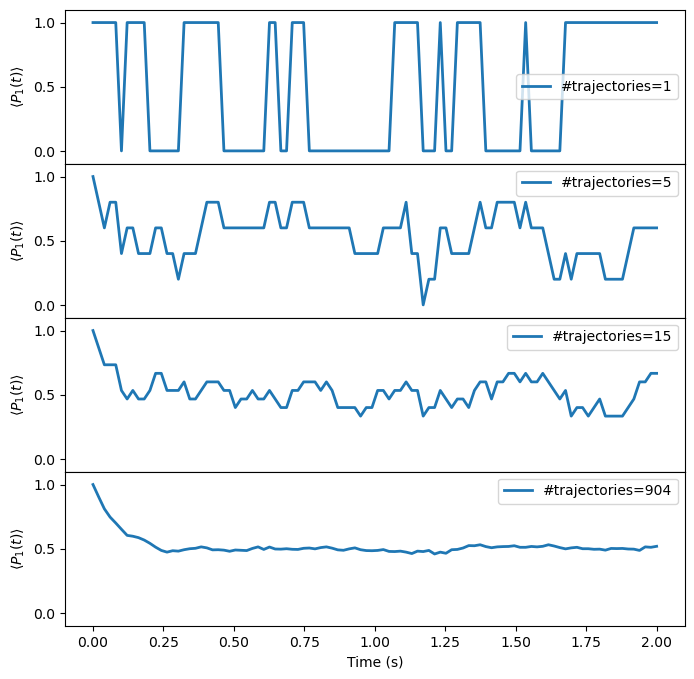

In [6]:
#Plot basic simulation of MC solver for different n. of trajectories
fig = plt.figure(figsize=(8, 8), frameon=False)
plt.subplots_adjust(hspace=0.0)

for i in range(4):
    ax = plt.subplot(4, 1, i + 1)
    ax.plot(
        tlist, mc_try.expect[i][0], lw=2,
        label="#trajectories={}".format(ntraj[i])
    )
    #ax.plot(tlist, me.expect[0], "r--", lw=2)
    ax.set_yticks([0, 0.5, 1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_ylabel(r"$\langle P_{1}(t)\rangle$")
    ax.legend()

ax.set_xlabel(r"Time (s)");

In [7]:
# MLE data preparation
y = mc_try.expect[3][0]
x = tlist
n = len (tlist)

In [8]:
# Initializing our example creating a parameter set for the initial guesses:
p = lmfit.Parameters()
p.add_many(('a', 5),('b', .5)) #a=gamma_relax= 5, b=k=.5


def residual(p):
    v = p.valuesdict()
    return (v['b']/(v['b']+v['a'])) + (1 - (v['b']/(v['b']+v['a'])))*np.exp(-x*(v['a']+v['b'])) - y


[[Variables]]
    a:  6.09739885 (init = 5)
    b:  6.04087595 (init = 0.5)


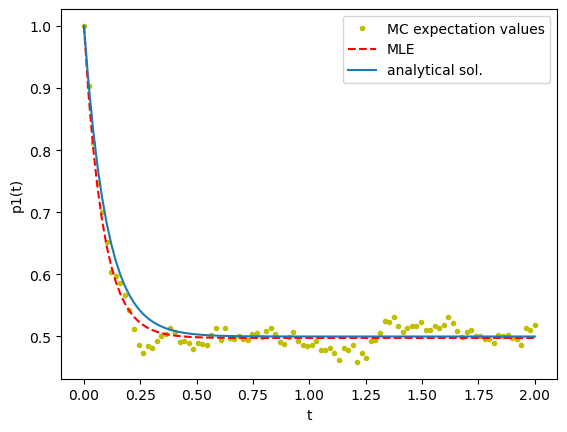

In [9]:
#Solving with minimize() gives the Maximum Likelihood solution.:

mi = lmfit.minimize(residual, p, method='Nelder')
lmfit.printfuncs.report_fit(mi.params, min_correl=0.5)

plt.plot(tlist, mc_try.expect[3][0], "y.", lw=2,label='MC expectation values')
plt.plot(x, residual(mi.params) + y, 'r--',label='MLE')
plt.plot(x, (k/(gamma_relax+k)) + ( 1 - (k/(gamma_relax+k)))*np.exp(-x*(k+gamma_relax)),label='analytical sol.')

plt.ylabel('p1(t)')
plt.xlabel('t')
plt.legend()
plt.show()

In [10]:
#analytical SOLUTION FOR THE SIGMAS
#Remeber to comment a lot on the code
ntraj_plot=np.arange(1,1000)

In [11]:
### Simulate -and save- different decays with multiple trajectories 1 to 1000
t_final2=15
tlist2 = np.linspace(0, t_final2, 1500)

mc2=[]
for i in range(len(ntraj_plot)):
    mc2.append(mcsolve(H, psi0, tlist2, c_ops, [a.dag() * a], ntraj_plot[i]))

Total run time:   0.04s
50.0%. Run time:   0.11s. Est. time left: 00:00:00:00
100.0%. Run time:   0.11s. Est. time left: 00:00:00:00
Total run time:   0.12s
33.3%. Run time:   0.09s. Est. time left: 00:00:00:00
66.7%. Run time:   0.09s. Est. time left: 00:00:00:00
100.0%. Run time:   0.09s. Est. time left: 00:00:00:00
Total run time:   0.10s
25.0%. Run time:   0.09s. Est. time left: 00:00:00:00
50.0%. Run time:   0.09s. Est. time left: 00:00:00:00
75.0%. Run time:   0.10s. Est. time left: 00:00:00:00
100.0%. Run time:   0.10s. Est. time left: 00:00:00:00
Total run time:   0.10s
20.0%. Run time:   0.09s. Est. time left: 00:00:00:00
40.0%. Run time:   0.09s. Est. time left: 00:00:00:00
60.0%. Run time:   0.09s. Est. time left: 00:00:00:00
80.0%. Run time:   0.09s. Est. time left: 00:00:00:00
100.0%. Run time:   0.09s. Est. time left: 00:00:00:00
Total run time:   0.10s
16.7%. Run time:   0.09s. Est. time left: 00:00:00:00
33.3%. Run time:   0.09s. Est. time left: 00:00:00:00
50.0%. Run t

Text(0, 0.5, '$\\sigma_{T_{UP}}$')

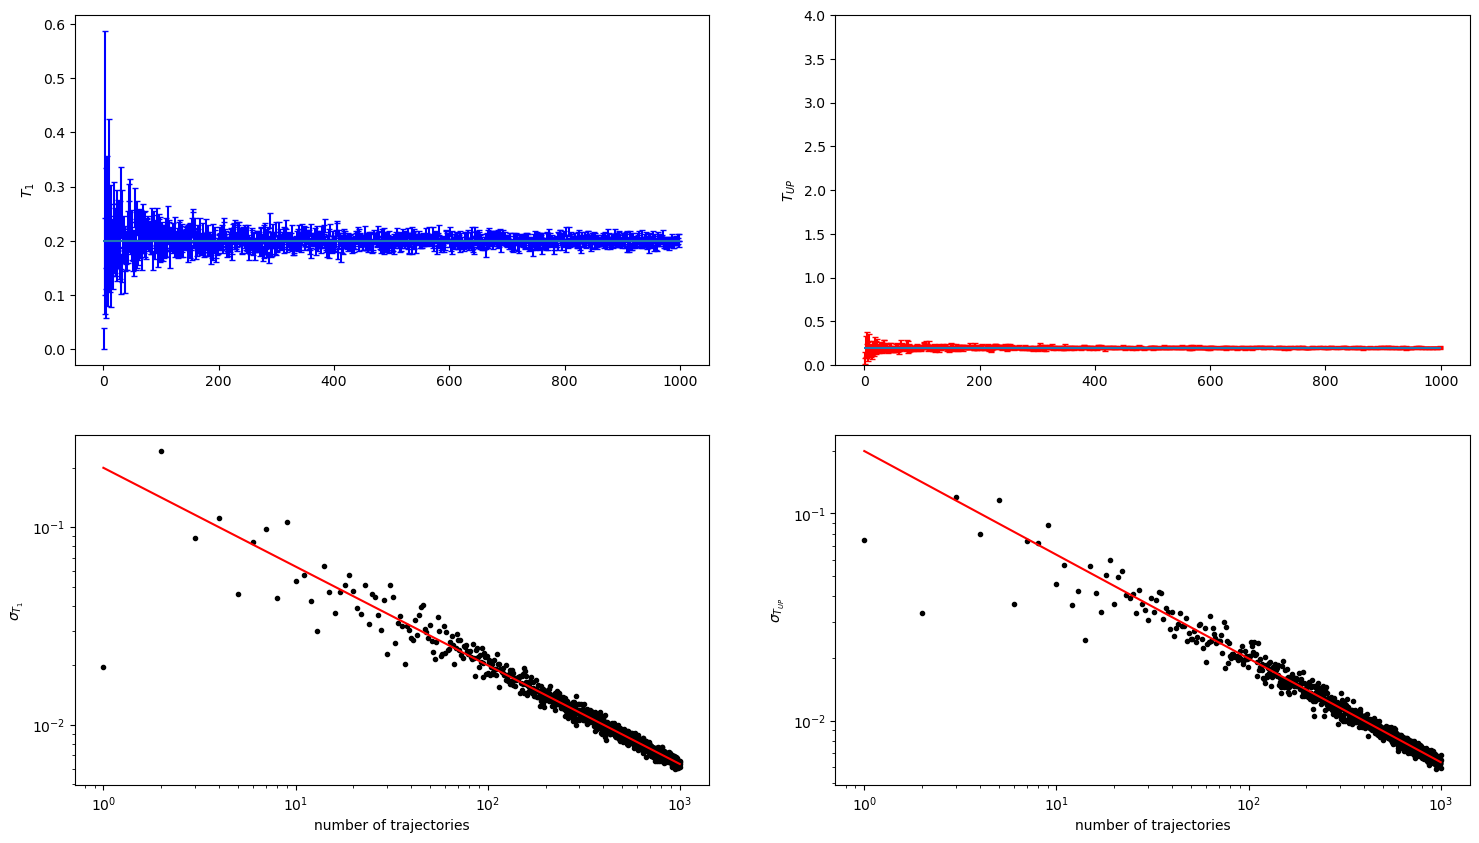

In [12]:
#Plot T1,T_exc and the relatives sigma vs number of trajectories
fig, axs = plt.subplots(2, 2,figsize=(18,10))

for i in range(len(ntraj_plot)):
    
    first_elements = [arr[0] if arr.size > 0 else t_final for arr in mc2[i].col_times]
    #first_elements = [arr[0] for arr in mc[i].col_times if len(arr) > 0]

    #second_elements = [arr[1]-arr[0] if arr.size > 1 else None for arr in mc[i].col_times] 
    second_elements = [arr[1]-arr[0] for arr in mc2[i].col_times if len(arr) > 1]

    axs[0,0].errorbar(ntraj_plot[i],np.mean(first_elements),yerr=np.sqrt(np.mean(first_elements)**2 /len(first_elements)), color='blue',
       capsize=2,label="#trajectories={}".format(ntraj_plot[i]))  
    
    axs[1,0].loglog(ntraj_plot[i],np.sqrt(np.mean(first_elements)**2 /ntraj_plot[i]),'.',color='black')
    



    axs[0,1].errorbar(ntraj_plot[i],np.mean(second_elements),yerr=np.sqrt(np.mean(second_elements)**2 /len(second_elements)), color='red',
       capsize=2,label="#trajectories={}".format(ntraj_plot[i]))  
    
    
    axs[1,1].loglog(ntraj_plot[i],np.sqrt(np.mean(second_elements)**2 /len(second_elements)),'.',color='black')




axs[1,0].plot(ntraj_plot, 1/gamma_relax/np.sqrt(ntraj_plot),color='red',markersize=1)
axs[1,1].plot(ntraj_plot, 1/k/np.sqrt(ntraj_plot),color='red',markersize=1)


axs[0,0].hlines(1/gamma_relax,xmin=0,xmax=1000)
axs[0,1].hlines(1/k,xmin=0,xmax=1000)

axs[0,1].set_ylim(0,4)

axs[1,0].set_xlabel('number of trajectories')
axs[1,1].set_xlabel('number of trajectories')
    
axs[0,0].set_ylabel('$T_1$')
axs[0,1].set_ylabel('$T_{UP}$')

axs[1,0].set_ylabel('$\sigma_{T_1}$')
axs[1,1].set_ylabel('$\sigma_{T_{UP}}$')

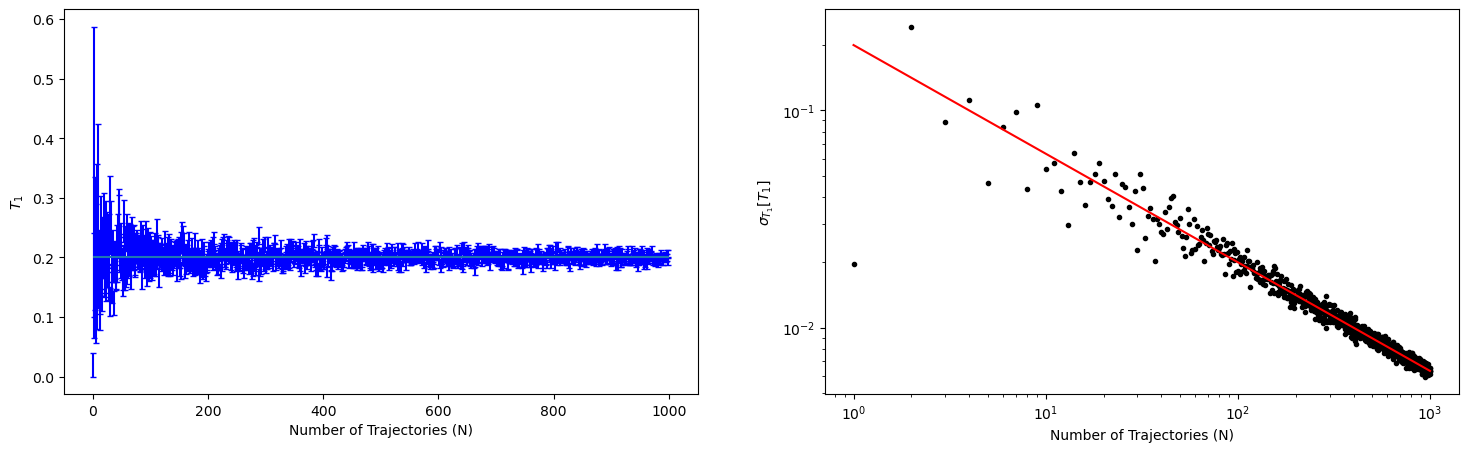

In [20]:
#Plot T1,T_exc and the relatives sigma vs number of trajectories
fig, axs = plt.subplots(1,2,figsize=(18,5))

for i in range(len(ntraj_plot)):
    
    first_elements = [arr[0] if arr.size > 0 else t_final for arr in mc2[i].col_times]
    #first_elements = [arr[0] for arr in mc[i].col_times if len(arr) > 0]

    #second_elements = [arr[1]-arr[0] if arr.size > 1 else None for arr in mc[i].col_times] 
    second_elements = [arr[1]-arr[0] for arr in mc2[i].col_times if len(arr) > 1]

    axs[0].errorbar(ntraj_plot[i],np.mean(first_elements),yerr=np.sqrt(np.mean(first_elements)**2 /len(first_elements)), color='blue',
       capsize=2,label="#trajectories={}".format(ntraj_plot[i]))  
    
    axs[1].loglog(ntraj_plot[i],np.sqrt(np.mean(first_elements)**2 /ntraj_plot[i]),'.',color='black')
   
    
    




axs[1].plot(ntraj_plot, 1/gamma_relax/np.sqrt(ntraj_plot),color='red',markersize=1)



axs[0].hlines(1/gamma_relax,xmin=0,xmax=1000)


axs[1].set_xlabel('Number of Trajectories (N)')

axs[0].set_xlabel('Number of Trajectories (N)')
    
axs[0].set_ylabel('$T_1$')

axs[1].set_ylabel('$\sigma_{T_1} [T_1]$')


plt.savefig("sigmaT1trajectories.pdf")

Text(0, 0.5, '$\\sigma_{T_1}$')

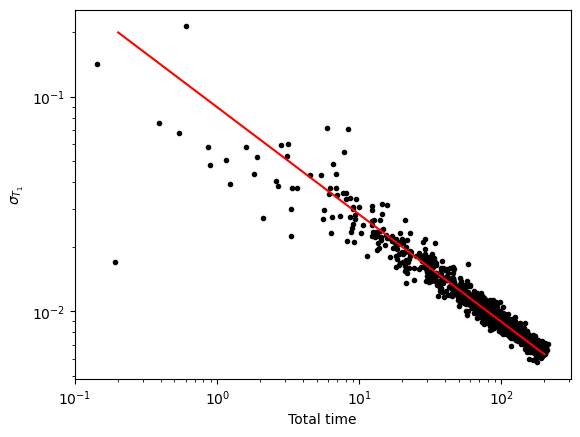

In [750]:
#Plot T1 vs total experimental time

for i in range(len(ntraj_plot)):
    
    first_elements = [arr[0] if arr.size > 0 else t_final for arr in mc2[i].col_times]
    T_1= np.mean(first_elements)
    T_tot = T_1* ntraj_plot
    plt.loglog(T_tot[i],np.sqrt(T_1**3 /T_tot[i]),'.',color='black')
    

plt.plot(T_tot, 1/gamma_relax**1.5/np.sqrt(T_tot),color='red',markersize=1)

plt.xlabel('Total time')
plt.ylabel('$\sigma_{T_1}$')

In [1078]:
from scipy.optimize import fsolve
import numpy as np

# There's no analytical solution to the previous equations, so instead, we have to use a numerical solver to find x_opt as a function of gamma
t_wait = 10 * T_1
t_reset = 0.01 * T_1


# Define the equation d_gamma=0 as a function
def equation(x, gamma, t):
    term1 = (gamma * np.sqrt((t + x) / x**2) * np.exp(gamma * x)) / (np.sqrt(np.exp(gamma * x) - 1))
    term2 = (2 * x**2 * np.sqrt((t + x) / x**2) * ((1 / (2 * x**2)) - (t + x) / x**3) * np.sqrt(np.exp(gamma * x) - 1)) / ((t + x))
    return (term1 + term2)/2

# Specify the value of gamma (we use the theoretical value of gamma_relax)
gamma_value = gamma_relax

# Choose an initial guess for the solution
initial_guess = 1 / gamma_value

# Solve the equation numerically 

result_wait = fsolve(equation, initial_guess, args=(gamma_value, t_wait))
xgamma_numerical_solution_wait =result_wait

result_reset = fsolve(equation, initial_guess, args=(gamma_value, t_reset))
xgamma_numerical_solution_reset=result_reset

/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_11760/2703416792.py:11: RuntimeWarning: invalid value encountered in sqrt
  term1 = (gamma * np.sqrt((t + x) / x**2) * np.exp(gamma * x)) / (np.sqrt(np.exp(gamma * x) - 1))
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_11760/2703416792.py:12: RuntimeWarning: invalid value encountered in sqrt
  term2 = (2 * x**2 * np.sqrt((t + x) / x**2) * ((1 / (2 * x**2)) - (t + x) / x**3) * np.sqrt(np.exp(gamma * x) - 1)) / ((t + x))
/Users/filippo/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [1275]:
xgamma_numerical_solution_wait

array([0.2848808])

In [1079]:
def d_gamma(x, gamma, t, T):
    return np.sqrt((x+t)/(x*x))*np.sqrt(np.exp(gamma*x)-1)/np.sqrt(T)

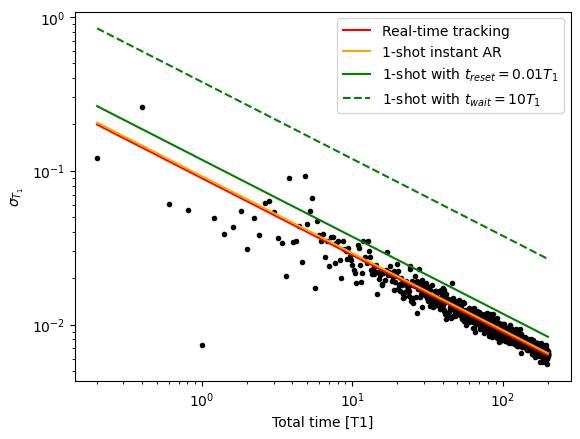

In [1080]:
#Plot T1 vs total experimental time in the case of multiple shots at the same point in time
T_tot = T_1* ntraj_plot

for i in range(len(ntraj_plot)):
    
    first_elements = [arr[0] if arr.size > 0 else t_final for arr in mc2[i].col_times]
    T_1= np.mean(first_elements)
    #plot of sigma_T1 extracted from the simulated trace
    plt.loglog(T_tot[i],np.sqrt(T_1**3 /T_tot[i]),'.',color='black')


# plot of the theoretical MLE for a single trace analysis
plt.plot(T_tot, 1/gamma_relax**1.5/np.sqrt(T_tot),color='red',markersize=0.7, label='Real-time tracking')

# plot of the theoretical curve for fixed total experimental time T = N*x_0, which means instant active reset
plt.plot(T_tot, 1.03/gamma_relax**1.5/np.sqrt(T_tot),color='orange',markersize=1, label='1-shot instant AR')

#plot of the theoretical (numerical x_opt) curve for multiple shots in one point, with t_reset=1% of T1 (ACTIVE RESET BEST)
plt.plot(T_tot, d_gamma(xgamma_numerical_solution_reset,gamma_relax,t_reset,T_tot)/gamma_relax**2 ,color='green',markersize=1, label='1-shot with $t_{reset}=0.01 T_1$')

#plot of the theoretical (numerical x_opt) curve for multiple shots in one point, with t_wait=10*T1 (PASSIVE RESET)
plt.plot(T_tot, d_gamma(xgamma_numerical_solution_wait,gamma_relax,t_wait,T_tot)/gamma_relax**2 ,color='green',linestyle='dashed',markersize=1, label='1-shot with $t_{wait}=10T_1$')

plt.xlabel('Total time [T1]')
plt.ylabel('$\sigma_{T_1}$')
plt.legend()

In [1260]:
##SET up fitting function
def exponential_numerical(t_wait,T_1):
    return np.exp(-t_wait/T_1)

#SET UP DATA
T_1= 1/gamma_relax
n_samp=1000

In [1261]:
#TRY AND PLOT THE FIT WITH THE SAMPLES POINTS AT THE OPTIMAL SAMPLING POINT
from scipy.optimize import curve_fit

def simulate_1point(n_samp,t_samp,T_1):
    samples=np.random.choice([0,1],n_samp,p=[1-exponential_numerical(t_samp,T_1),exponential_numerical(t_samp,T_1)])
    f=np.mean(samples)
    f_var=np.sum((f-samples)**2/(n_samp-1))
    f_dev=np.sqrt(f_var)/np.sqrt(n_samp)
    
    params, covariance = curve_fit(exponential_numerical, np.array([t_samp]), np.array([f]),sigma=np.array([f_dev]),absolute_sigma=True)
    sigma_gamma=np.sqrt(covariance)
    sigma_T1=sigma_gamma[0]
    return f,f_dev,sigma_T1[0]

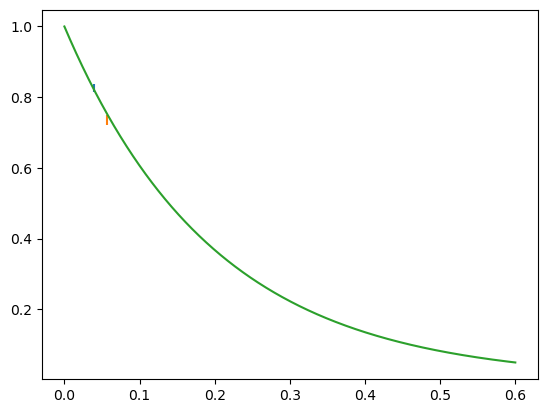

In [1262]:
t_samp_reset= xgamma_numerical_solution_reset[0]*T_1
M=simulate_1point(n_samp,t_samp_reset,T_1)[0]
m=simulate_1point(n_samp,t_samp_reset,T_1)[1]
plt.errorbar(t_samp_reset,M,yerr=m)

t_samp_wait=xgamma_numerical_solution_wait[0]*T_1
M=simulate_1point(n_samp,t_samp_wait,T_1)[0]
m=simulate_1point(n_samp,t_samp_wait,T_1)[1]
plt.errorbar(t_samp_wait,M,yerr=m)

t_wait_plot=np.linspace(0,3*T_1,1000)
plt.plot(t_wait_plot,exponential_numerical(t_wait_plot,T_1))

In [1263]:
#### As a function of total time

sigmas_reset=[]
sigmas_wait=[]
#Creating samples
for n_samp in range(1,1000):
    sigma_T1_reset=simulate_1point(n_samp,xgamma_numerical_solution_reset[0]*T_1,T_1)[2]
    sigmas_reset.append(sigma_T1_reset)

    sigma_T1_wait=simulate_1point(n_samp,xgamma_numerical_solution_wait[0]*T_1,T_1)[2]
    sigmas_wait.append(sigma_T1_wait)

/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_11760/1500849731.py:7: RuntimeWarning: invalid value encountered in divide
  f_var=np.sum((f-samples)**2/(n_samp-1))
/Users/filippo/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/filippo/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:931: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma


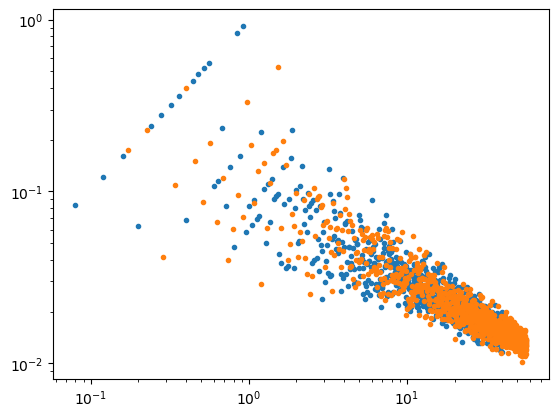

In [1265]:
plt.loglog(t_samp_reset*np.arange(1,1000),np.array(sigmas_reset),".")
plt.loglog(t_samp_wait*np.arange(1,1000),np.array(sigmas_wait),".")

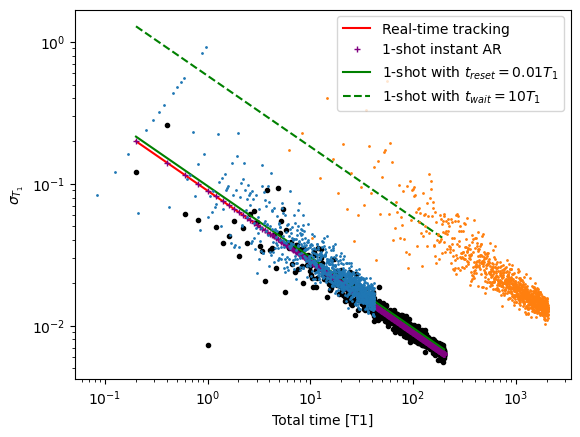

In [1273]:
#Plot T1 vs total experimental time in the case of multiple shots at the same point in time
T_tot = T_1* ntraj_plot

for i in range(len(ntraj_plot)):
    
    first_elements = [arr[0] if arr.size > 0 else t_final for arr in mc2[i].col_times]
    T_1= np.mean(first_elements)
    #plot of sigma_T1 extracted from the simulated trace
    plt.loglog(T_tot[i],np.sqrt(T_1**3 /T_tot[i]),'.',color='black')


# plot of the theoretical MLE for a single trace analysis
plt.plot(T_tot, 1/gamma_relax**1.5/np.sqrt(T_tot),color='red',markersize=0.7, label='Real-time tracking')

# plot of the theoretical curve for fixed total experimental time T = N*x_0, which means instant active reset
plt.plot(T_tot, 1/gamma_relax**1.5/np.sqrt(T_tot),"+", color='purple',markersize=4, label='1-shot instant AR')

#plot of the theoretical (numerical x_opt) curve for multiple shots in one point, with t_reset=1% of T1 (ACTIVE RESET BEST)
plt.plot(T_tot, d_gamma(xgamma_numerical_solution_reset*T_1,gamma_relax,t_reset,T_tot)/gamma_relax**2 ,color='green',markersize=1, label='1-shot with $t_{reset}=0.01 T_1$')

#plot of the theoretical (numerical x_opt) curve for multiple shots in one point, with t_wait=10*T1 (PASSIVE RESET)
plt.plot(T_tot, d_gamma(xgamma_numerical_solution_wait*T_1,gamma_relax,t_wait,T_tot)/gamma_relax**2 ,color='green',linestyle='dashed',markersize=1, label='1-shot with $t_{wait}=10T_1$')

plt.loglog((t_samp_reset+t_reset)*ntraj_plot,np.array(sigmas_reset),".", markersize=2)
plt.loglog((t_samp_wait+t_wait)*ntraj_plot,np.array(sigmas_wait),".", markersize=2)

plt.xlabel('Total time [T1]')
plt.ylabel('$\sigma_{T_1}$')
plt.legend()

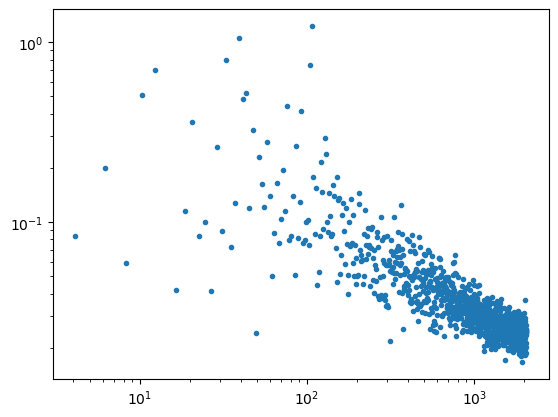

In [1127]:
#### As a function of total time

#Setting paramters
T_1= 1/gamma_relax
t_samp=xgamma_numerical_solution_wait[0]*T_1
t_resetwait=10*T_1

sigmas=[]
#Creating samples
for n_samp in range(1,1000):
    samples=np.random.choice([0,1],n_samp,p=[1-exponential_numerical(t_samp,T_1),exponential_numerical(t_samp,T_1)])
    f=np.mean(samples)
    f_dev=np.mean(f)/np.sqrt(n_samp)
    params, covariance = curve_fit(exponential_numerical, np.array([t_samp]), np.array([f]),sigma=np.array([f_dev]),absolute_sigma=True)
    sigma_gamma=np.sqrt(covariance)
    sigma_T1=sigma_gamma[0]
    sigmas.append(sigma_T1[0])

T_tot = (t_samp+t_resetwait)*np.arange(1,1000)
plt.loglog(T_tot,np.array(sigmas),".")